# Hazard assessment: Visualise climate indicators (change in projection)

- A workflow from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and [MULTI_HAZARD](https://github.com/CLIMAAX/MULTI_HAZARD) GitHub repository.
- See our [how to use risk workflows](https://handbook.climaax.eu/notebooks/workflows_how_to.html) page for information on how to run this notebook.

## Preparation Work

### Load libraries

In [1]:
import os

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

ERROR 1: PROJ: proj_create_from_database: Open of /etc/ecmwf/ssd/ssd1/jupyterhub/ecm5975-jupyterhub/tmpdirs/ecm5975.23836582/conda/envs/climaax/share/proj failed


### Area of interest

In [2]:
region_name = 'IT'

### Path configuration

In [3]:
# Path to the folder containing the NetCDF files
indicators_ref_path = f'data_{region_name}/indicators/cordex-hist'
indicators_future_path = {
    '2021-2050': f'data_{region_name}/indicators/cordex-45-near',
    '2041-2070': f'data_{region_name}/indicators/cordex-45-mid',
    '2071-2100': f'data_{region_name}/indicators/cordex-45-far',
}

# Path to save the maps
output_maps = f'data_{region_name}/indicators/maps_change'
os.makedirs(output_maps, exist_ok=True)

:::{tip}
TODO
:::

### Plotting helpers

In [4]:
global_title = 'RCP4.5'

def configure_map(ax, title=None):
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    if title is not None:
        ax.set_title(title, fontsize="medium")

In [5]:
def compute_change(indicator, relative=False):
    changes = []
    reference = xr.open_dataset(os.path.join(indicators_ref_path, indicator))
    for period, path in indicators_future_path.items():
        future = xr.open_dataset(os.path.join(path, indicator))
        change = (future - reference)
        if relative:
            change /= reference
        changes.append(change.expand_dims({'period': [period]}))
    return xr.concat(changes, dim='period')

## Change in number of days above 35°, 40° and 45°C

In [6]:
thresholds = [35, 40, 45]  # °C

tx_change = xr.concat(
    [compute_change(f'Temp_DaysAbove{threshold}.nc').expand_dims({'threshold': [threshold]}) for threshold in thresholds],
    dim='threshold'
)['tx_days_above']

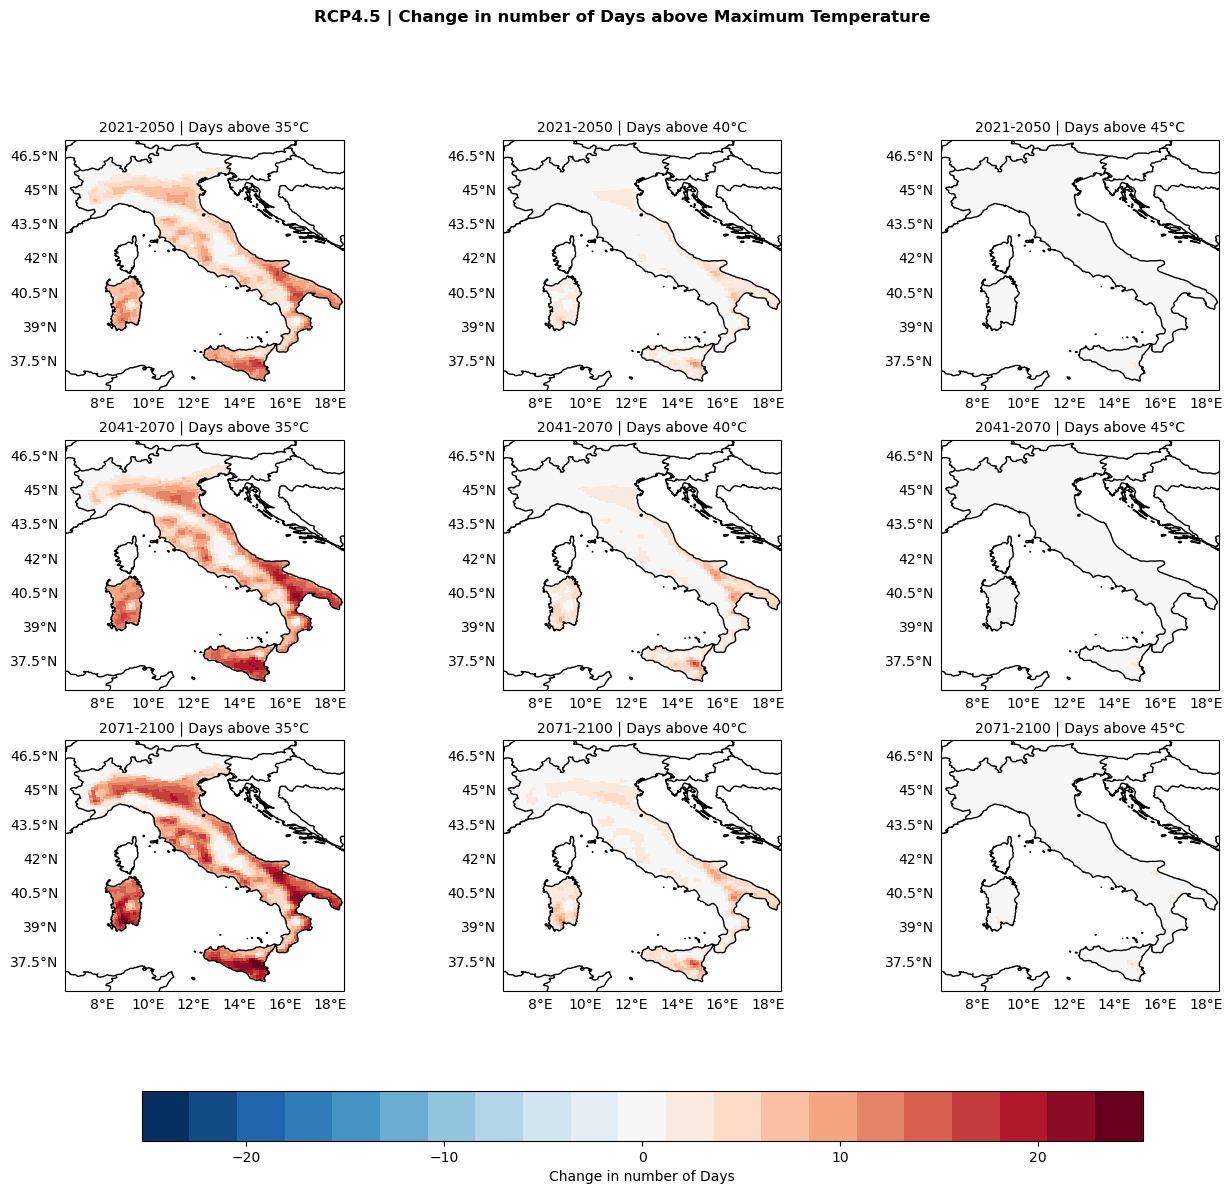

In [7]:
fig, axss = plt.subplots(nrows=len(thresholds), ncols=len(indicators_future_path),
        figsize=(16, 13), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'{global_title} | Change in number of Days above Maximum Temperature', fontweight='bold')

lim = np.abs(tx_change).max()
plot_kwargs = {
    'cmap': plt.get_cmap('RdBu_r', 21),
    'vmin': -lim,
    'vmax': lim,
    'transform': ccrs.PlateCarree()
}

for axs, period in zip(axss, indicators_future_path):
    for ax, threshold in zip(axs, thresholds):
        configure_map(ax, title=f'{period} | Days above {threshold}°C')
        da = tx_change.sel(period=period, threshold=threshold)
        im = ax.pcolormesh(da['longitude'], da['latitude'], da, **plot_kwargs)

fig.colorbar(im, ax=axss, orientation='horizontal', fraction=0.05, pad=0.1, label='Change in number of Days')

fig.savefig(os.path.join(output_maps, "Temp_DaysAbove_change.png"))

## Change in 95th temperature percentile

In [8]:
tmax_change = compute_change(f'Temp_P95.nc')["tmax2m"]

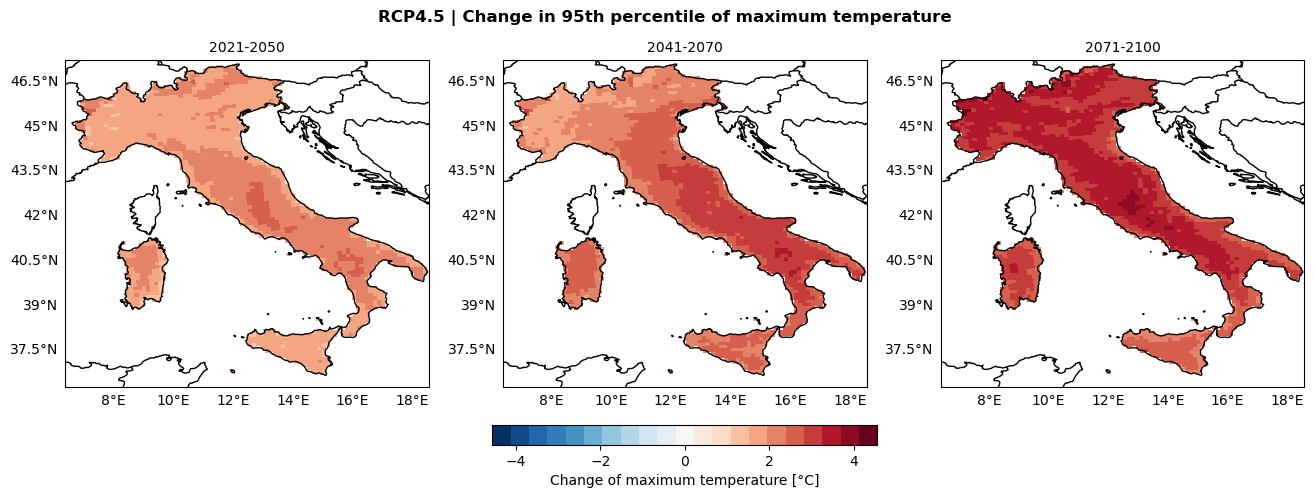

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=len(indicators_future_path),
        figsize=(16, 5), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'{global_title} | Change in 95th percentile of maximum temperature', fontweight='bold')

lim = np.abs(tmax_change).max()
plot_kwargs = {
    'cmap': plt.get_cmap('RdBu_r', 21),
    'vmin': -lim,
    'vmax': lim,
    'transform': ccrs.PlateCarree()
}

for ax, period in zip(axs, indicators_future_path):
    configure_map(ax, title=period)
    da = tmax_change.sel(period=period)
    im = ax.pcolormesh(da['longitude'], da['latitude'], da, **plot_kwargs)

fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1, label='Change of maximum temperature [°C]')

fig.savefig(os.path.join(output_maps, "Temp_P95_change.png"))

## Change in precipitation percentiles

In [10]:
precip_change = compute_change(f'Precip_P99.nc')["tp"]

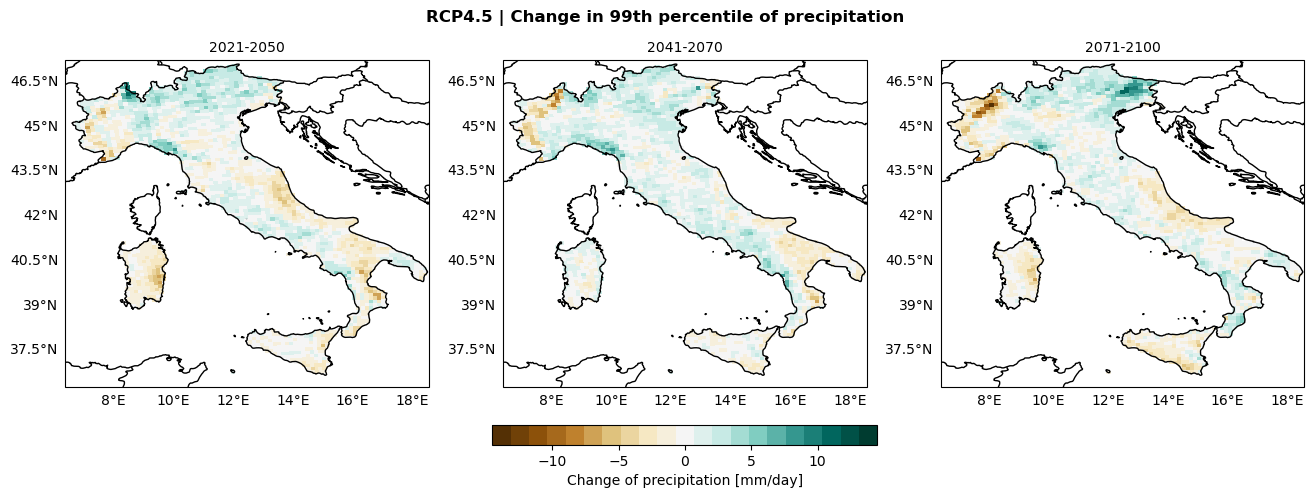

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=len(indicators_future_path),
        figsize=(16, 5), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'{global_title} | Change in 99th percentile of precipitation', fontweight='bold')

lim = np.abs(precip_change).max()
plot_kwargs = {
    'cmap': plt.get_cmap('BrBG', 21),
    'vmin': -lim,
    'vmax': lim,
    'transform': ccrs.PlateCarree()
}

for ax, period in zip(axs, indicators_future_path):
    configure_map(ax, title=period)
    da = precip_change.sel(period=period)
    im = ax.pcolormesh(da['longitude'], da['latitude'], da, **plot_kwargs)

fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1, label='Change of precipitation [mm/day]')

fig.savefig(os.path.join(output_maps, "Precip_P99_change.png"))

## Percentage change in precipitation return levels

In [12]:
precip_rp_change = compute_change(f'Precip_return_levels_gumbel.nc', relative=True)['return_period_50_y']

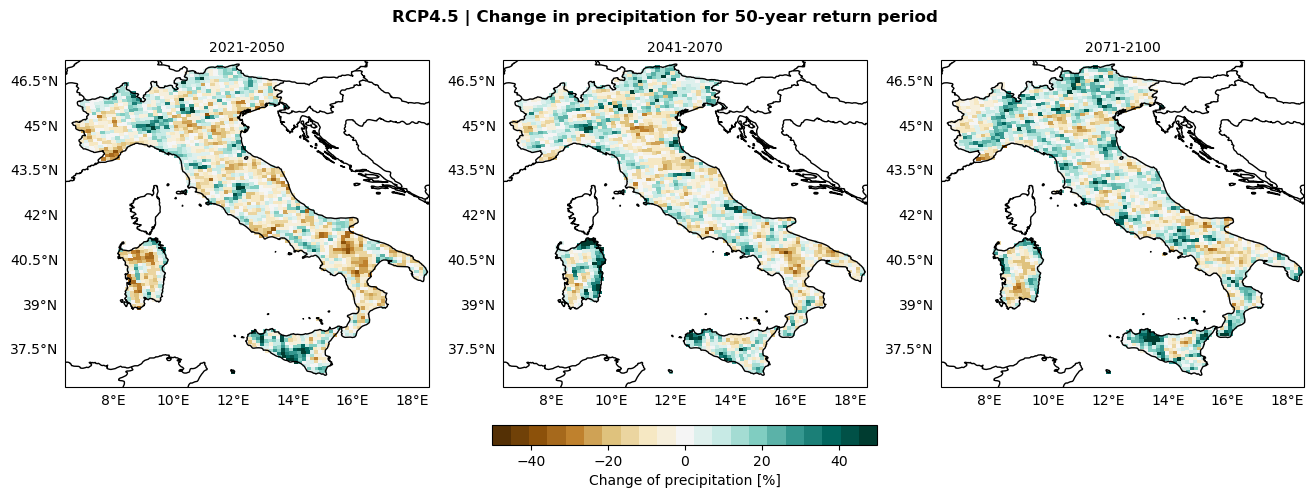

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=len(indicators_future_path),
        figsize=(16, 5), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f'{global_title} | Change in precipitation for 50-year return period', fontweight='bold')

lim = np.abs(precip_rp_change).max()
plot_kwargs = {
    'cmap': plt.get_cmap('BrBG', 21),
    'vmin': -50,
    'vmax': 50,
    'transform': ccrs.PlateCarree()
}

for ax, period in zip(axs, indicators_future_path):
    configure_map(ax, title=period)
    da = 100. * precip_rp_change.sel(period=period)
    im = ax.pcolormesh(da['longitude'], da['latitude'], da, **plot_kwargs)

fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.1, label='Change of precipitation [%]')

fig.savefig(os.path.join(output_maps, "Precip_return_levels_change.png"))